<a href="https://colab.research.google.com/github/bgittel/Evaluative-Text-Structures/blob/main/Portrait_Divergence_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa
!pip install krippendorff

Mounted at /content/drive


# Load assertion anno

In [4]:
import pandas as pd
import numpy as np
import krippendorff

# Load data from Excel files
file_path1 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_BG_35.xlsx'
df_anno_BG = pd.read_excel(file_path1)
file_path2 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_FS_35.xlsx'
df_anno_FS = pd.read_excel(file_path2)
file_path3 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_MA_35.xlsx'
df_anno_MA = pd.read_excel(file_path3)

# Merge the DataFrames in two steps
df_assertion = pd.merge(df_anno_BG, df_anno_MA, on='Document_title', how='inner')
df_assertion = pd.merge(df_assertion, df_anno_FS, on='Document_title', how='inner')

"""
#RENAMING OF DOC TITLES
df_assertion["Document_title"] = df_assertion["Document_title"].apply(lambda x:
    "Kafka_Der_neue_Advokat" if x == "Der neue Advokat" else
    "Kafka_Ein_Bericht_für_eine_Akademie" if x == "Ein Bericht für eine Akademie" else x
)

# Replace wrong filenames
df_assertion.loc[df_assertion["Document_title"] == "Hesse_Der Steppenwolf (annotierter Auszug!)", "Document_title"] = "Hesse_Der_Steppenwolf_Beginn.txt"

# Replace "_clean.txt" and ".txt" in the Document_title column
df_assertion["Document_title"] = df_assertion["Document_title"].str.replace("_clean.txt", "", regex=False)
df_assertion["Document_title"] = df_assertion["Document_title"].str.replace(".txt", "", regex=False)


"""

# Drop the first row
df_assertion = df_assertion.iloc[1:]

# Calculate means for specified columns
columns_to_average = {
    'implicit_assertion_mean': ['implicit_assertion_x', 'implicit_assertion_y', 'implicit_assertion'],
    'assertive_force_mean': ['assertive_force_x', 'assertive_force_y', 'assertive_force'],
    'assertive_clarity_mean': ['assertive_clarity_x', 'assertive_clarity_y', 'assertive_clarity']
}

for new_col, cols in columns_to_average.items():
    df_assertion[new_col] = df_assertion[cols].mean(axis=1)

# Define column groups for Krippendorff's Alpha calculation
column_groups = {
    'implicit_assertion': ['implicit_assertion_x', 'implicit_assertion_y', 'implicit_assertion'],
    'assertive_force': ['assertive_force_x', 'assertive_force_y', 'assertive_force'],
    'assertive_clarity': ['assertive_clarity_x', 'assertive_clarity_y', 'assertive_clarity']
}

# Function to calculate Krippendorff's Alpha for ordinal scales
def calculate_krippendorff_alpha_for_group(df, columns):
    # Get ratings data
    ratings = df[columns].astype(float).values.T  # Transpose to make each row a rater for Krippendorff's Alpha
    print(ratings)
    return krippendorff.alpha(reliability_data=ratings, level_of_measurement='ordinal')

# Calculate Krippendorff's Alpha for each group of columns
alpha_results = {}
for group_name, cols in column_groups.items():
    try:
        alpha_results[group_name] = calculate_krippendorff_alpha_for_group(df_assertion, cols)
    except ValueError as e:
        alpha_results[group_name] = str(e)

# Display the Krippendorff's Alpha results
print("\nKrippendorff's Alpha Results:")
for group_name, alpha in alpha_results.items():
    print(f"{group_name}: {alpha}")

df_assertion.head()


[[2. 5. 1. 2. 1. 4. 1. 1. 1. 3. 4. 1. 1. 1. 1. 3. 3. 1. 1. 1. 1. 2. 3. 2.
  1. 2. 3. 4. 5. 4. 1. 1. 5. 5. 2.]
 [1. 1. 1. 3. 2. 1. 2. 1. 1. 2. 4. 2. 3. 1. 1. 1. 2. 4. 1. 2. 4. 1. 1. 3.
  1. 3. 4. 5. 1. 5. 2. 1. 5. 2. 1.]
 [1. 5. 1. 3. 2. 5. 1. 1. 2. 2. 5. 1. 2. 1. 5. 5. 5. 1. 5. 1. 3. 2. 1. 1.
  1. 2. 1. 5. 3. 5. 1. 1. 5. 5. 3.]]
[[ 9.  0. 10.  6. 10.  2. 10. 10.  8.  5.  2. 10. 10. 10. 10.  5.  5.  7.
   9. 10.  9.  8.  5.  9. 10.  5.  7.  3.  0.  1.  7. 10.  0.  1.  9.]
 [10.  9. 10.  4.  8. 10.  9.  9.  6.  6.  2. 10.  6. 10.  8. 10.  8.  6.
  10.  6.  3. 10.  8.  4. 10.  3.  2.  0. 10.  0.  6. 10.  0.  7.  8.]
 [ 9.  0. 10.  5.  8.  0. 10. 10.  7.  7.  0. 10.  8. 10.  0.  0.  0. 10.
   0.  9.  7.  8.  8.  8. 10.  6.  9.  0.  2.  0. 10. 10.  0.  0.  7.]]
[[ 6.  1.  8.  6.  7.  1. 10.  8.  1.  2.  3.  8.  8. 10.  9.  5.  2.  7.
   5.  8.  5.  6.  4.  2. 10.  6.  3.  2.  0.  0.  7.  9.  0.  0.  7.]
 [ 9.  8. 10.  4.  7. 10.  7.  6.  6.  6.  2.  9.  6. 10.  8. 10.  6.  9.
   7.  6.  3. 

,Document_title,implicit_assertion_x,assertive_force_x,assertive_clarity_x,guess_implicit_assertion_x,implicit_assertion_y,assertive_force_y,assertive_clarity_y,guess_implicit_assertion_y,implicit_assertion,assertive_force,assertive_clarity,guess_implicit_assertion,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean
1,Aichinger_Das_Fenstertheater.txt,2,9,6,NaN,1,10,9,Man sollte andere nicht verurteilen und sich n...,1,9,9,"man soll andere ihr Leben leben lassen, wie si...",1.333333,9.333333,8.0
2,Altenberg_Die_Natur.txt,5,0,1,NaN,1,9,8,"Wo der Mensch ist, herrscht Leid, und die unbe...",5,0,0,NaN,3.666667,3.0,3.0
3,Auerbach_Der_Kindesmord.txt,1,10,8,NaN,1,10,10,Man sollte Ammen bessere Arbeitsbedingungen bi...,1,10,10,Ammen und deren Kinder sollen nicht ausgenutzt...,1.0,10.0,9.333333
4,Bachmann_Arkadien_clean_neu.txt,2,6,6,NaN,3,4,4,"Die Sehnsucht nach der Heimat bleibt, auch wen...",3,5,5,Stadtleben und Arbeit halten von Natur fern,2.666667,5.0,5.0
5,Bierbaum_Der_Mohr.txt,1,10,7,NaN,2,8,7,"Man sollte sich nicht gegenseitig bekämpfen, s...",2,8,5,der Friede zwischen den Nationen (Deutschland ...,1.666667,8.666667,6.333333


In [5]:
# select mean cols for clustering

df_assertion = df_assertion[["Document_title", "implicit_assertion_mean",	"assertive_force_mean",	"assertive_clarity_mean"]]

# Define category boundaries and labels based on the scale:
# Adjust intervals as needed to best fit the means in your data.
"""bins = [0.99, 1.5, 2.5, 3.5, 4.5, 5.0]  # Define bin edges for ranges
labels = [
    'trifft zu',            # 1
    'trifft eher zu',       # 2
    'teils-teils',          # 3
    'trifft eher nicht zu', # 4
    'trifft nicht zu'       # 5
]
"""

bins = [0.99, 3, 5.0]  # Define bin edges for ranges
labels = [
    'IA',            # 1
    'NO-IA'       # 5
]

# Use pd.cut to categorize based on defined bins and labels
df_assertion['implicit_assertion_cat'] = pd.cut(
    df_assertion['implicit_assertion_mean'],
    bins=bins,
    labels=labels,
    right=True  # Include the right edge in each bin interval
)

bins = [-1, 5, 11]  # Define bin edges for ranges
labels = [
    'NO-IA',
    'IA'
]

bins2 = [-1, 5, 11]  # Define bin edges for ranges
labels2 = [
    'NO-IA',
    'IA'
]

# Use pd.cut to categorize based on defined bins and labels
df_assertion['assertive_clarity_cat'] = pd.cut(
    df_assertion['assertive_clarity_mean'],
    bins=bins,
    labels=labels,
    right=True  # Include the right edge in each bin interval
)

# Use pd.cut to categorize based on defined bins and labels
df_assertion['assertive_force_cat'] = pd.cut(
    df_assertion['assertive_force_mean'],
    bins=bins2,
    labels=labels2,
    right=True  # Include the right edge in each bin interval
)

df_assertion

,Document_title,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean,implicit_assertion_cat,assertive_clarity_cat,assertive_force_cat
1,Aichinger_Das_Fenstertheater.txt,1.333333,9.333333,8.0,IA,IA,IA
2,Altenberg_Die_Natur.txt,3.666667,3.0,3.0,NO-IA,NO-IA,NO-IA
3,Auerbach_Der_Kindesmord.txt,1.0,10.0,9.333333,IA,IA,IA
4,Bachmann_Arkadien_clean_neu.txt,2.666667,5.0,5.0,IA,NO-IA,NO-IA
5,Bierbaum_Der_Mohr.txt,1.666667,8.666667,6.333333,IA,IA,IA
6,Bobrowski_Brief_aus_Amerika.txt,3.333333,4.0,3.666667,NO-IA,NO-IA,NO-IA
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,1.333333,9.666667,8.666667,IA,IA,IA
8,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,1.0,9.666667,8.0,IA,IA,IA
9,Brecht_Müllers_natürliche_Haltung.txt,1.333333,7.0,4.666667,IA,NO-IA,IA
10,Dorn_Vorsicht_Steinschlag.txt,2.333333,6.0,4.333333,IA,NO-IA,IA


In [6]:
df_assertion['assertive_force_mean'].describe()

,assertive_force_mean
count,35.0
unique,20.0
top,10.0
freq,5.0


# Clustering of Portrait Divergence .

In [109]:
import pandas as pd
import numpy as np
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files


In [110]:
#def action_delete_all_files(directory):
  '''
  Delete all files.
  '''
  try:
      # Check if the directory exists
      if os.path.exists(directory) and os.path.isdir(directory):
          # Iterate over all files and directories within the directory
          for filename in os.listdir(directory):
              file_path = os.path.join(directory, filename)

              # Check if it's a file and delete it
              if os.path.isfile(file_path) or os.path.islink(file_path):
                  os.remove(file_path)
                  print(f"Deleted file: {file_path}")
              # Check if it's a directory (optional) and skip or delete recursively
              elif os.path.isdir(file_path):
                  shutil.rmtree(file_path)  # Use this if you want to delete subdirectories
                  print(f"Deleted directory: {file_path}")
      else:
          print("Directory does not exist or is not a directory.")
  except Exception as e:
      print(f"Error while deleting files: {e}")

IndentationError: unexpected indent (<ipython-input-110-823550964>, line 2)

In [111]:
#Checks if file is available if not then uploads it.
def check_for_file(file_name):
    # Define the file to be deleted
    file_namex = file_name

    # Path to the folder where the file is located
    content_folder_path = '/content/'
    file_path = os.path.join(content_folder_path, file_namex)

    # Check if the file exists
    if not os.path.isfile(file_path):
        # If the file does not exist, ask for upload
        print(f"File {file_path} does not exist. Upload {file_name} may be generated from last step")
        file_to_open = files.upload()
    else:
      print(f"{file_namex} Already uploaded.\n")

In [112]:
# Path to the folder in Google Drive where the files are stored
drive_folder_path = '/content/'
#action_delete_all_files(drive_folder_path)

In [7]:
from google.colab import files
uploaded = files.upload()


Saving portrait_divergence_matrix_split_network_graphml_pos_u_neg_Wertungen_17Jun2025.xlsx to portrait_divergence_matrix_split_network_graphml_pos_u_neg_Wertungen_17Jun2025.xlsx
Saving portrait_divergence_matrix_split_network_graphml_Relationen_18Jun2025.xlsx to portrait_divergence_matrix_split_network_graphml_Relationen_18Jun2025.xlsx
Saving portrait_divergence_matrix_split_network_graphml_Wertungen_abs_negative_18Jun2025.xlsx to portrait_divergence_matrix_split_network_graphml_Wertungen_abs_negative_18Jun2025.xlsx
Saving portrait_divergence_matrix_split_network_graphml_Wertungen_positive_18Jun2025.xlsx to portrait_divergence_matrix_split_network_graphml_Wertungen_positive_18Jun2025.xlsx


In [16]:
import pandas as pd

# Replace these with your actual filenames
df1 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_Relationen_18Jun2025.xlsx', index_col=0)
df2 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_Wertungen_abs_negative_18Jun2025.xlsx', index_col=0)
df3 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_Wertungen_positive_18Jun2025.xlsx', index_col=0)
df4 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_pos_u_neg_Wertungen_17Jun2025.xlsx', index_col=0)

In [17]:
# Relationen und pos und neg Wertungen zusammen (counts)
#average_array = np.mean([df1.values, df4.values], axis=0)
#average_df = pd.DataFrame(average_array, index=df1.index, columns=df1.columns)

# Relationen und pos Wertungen und neg Wertungen (counts)
average_array = np.mean([df1.values, df2.values, df3.values], axis=0)
average_df = pd.DataFrame(average_array, index=df1.index, columns=df1.columns)

# nur Relationen
#average_df = df1

# nur pos und neg Wertungen zusammen (counts)
#average_df = df4

# Drop rows where all elements are NaN
average_df = average_df.dropna(how='all')

# Drop columns where all elements are NaN
average_df = average_df.dropna(axis=1, how='all')

In [18]:
# Step 1: Clean both indexes by stripping '_split_network.graphml'
average_df.index = average_df.index.astype(str).str.split('_split_network.graphml').str[0]
df_assertion['Document_title'] = df_assertion['Document_title'].astype(str).str.split('_split_network.graphml').str[0]

# Step 2: Create a mapping from cleaned Document_title to assertive_clarity_cat
mapping_series = df_assertion.set_index('Document_title')['assertive_force_cat']

# Step 3: Create new index by combining assertive_clarity_cat + first 15 chars of filename
new_index = []
for fname in average_df.index:
    cat = mapping_series.get(fname, "UNKNOWN")  # fallback if not found
    new_name = f"{cat}_{fname[:15]}"
    new_index.append(new_name)

# Step 4: Assign new index to average_df
average_df.index = new_index


In [19]:
average_df.head()

,Aichinger_Das_Fenstertheater.txt_split_network.graphml,Altenberg_Die_Natur.txt_split_network.graphml,Auerbach_Der_Kindesmord.txt_split_network.graphml,Bachmann_Arkadien_clean_neu.txt_split_network.graphml,Bierbaum_Der_Mohr.txt_split_network.graphml,Bobrowski_Brief_aus_Amerika.txt_split_network.graphml,Brecht_Herr_Keuner_und_die_Schauspielerin.txt_split_network.graphml,Brecht_Müllers_natürliche_Haltung.txt_split_network.graphml,Böll_Wanderer_kommst_du_nach_Spa_clean.txt_split_network.graphml,Dorn_Vorsicht_Steinschlag.txt_split_network.graphml,...,Löns_Die_beiden_Höfe_clean.txt_split_network.graphml,Mann_Der_Geburtstag_der_Frau_Baronin.txt_split_network.graphml,Reventlow_Der_feine_Dieb.txt_split_network.graphml,Roth_Der_stumme_Prophet_Fragment_gb_clean_neu.txt_split_network.graphml,Stamm_Das_schönste_Mädchen.txt_split_network.graphml,Storm_Im_Saal.txt_split_network.graphml,Tucholsky_Märchen.txt_split_network.graphml,Walser_Der_Nachen.txt_split_network.graphml,Wendt_Tote_Vögel.txt_split_network.graphml,Wolf_Der_Stern_der_Schönheit.txt_split_network.graphml
IA_Aichinger_Das_Fenste,0.000000,0.302128,0.358248,0.356396,0.328841,0.217059,0.360523,0.434683,0.452912,0.533924,...,0.378243,0.400497,0.306857,0.375509,0.265838,0.315281,0.303711,0.342028,0.393220,0.347685
NO-IA_Altenberg_Die_Natur.,0.302128,0.000000,0.397095,0.392256,0.290457,0.285230,0.408266,0.501283,0.439167,0.528664,...,0.411890,0.426145,0.308087,0.304166,0.262970,0.383420,0.310072,0.357341,0.368328,0.420055
IA_Auerbach_Der_Kindesm,0.358248,0.397095,0.000000,0.367101,0.306861,0.324188,0.301862,0.331990,0.405172,0.509448,...,0.365691,0.425809,0.338103,0.284861,0.290516,0.367200,0.348625,0.356025,0.334539,0.326895
NO-IA_Bachmann_Arkadien_cl,0.356396,0.392256,0.367101,0.000000,0.316928,0.308989,0.305298,0.344456,0.402857,0.479160,...,0.375809,0.321930,0.315821,0.410696,0.254098,0.343669,0.343137,0.370800,0.344267,0.362123
IA_Bierbaum_Der_Mohr.tx,0.328841,0.290457,0.306861,0.316928,0.000000,0.255677,0.320612,0.328115,0.345299,0.488827,...,0.352287,0.377328,0.245625,0.398126,0.250392,0.236529,0.323426,0.320068,0.247383,0.316088


In [243]:
data = average_df

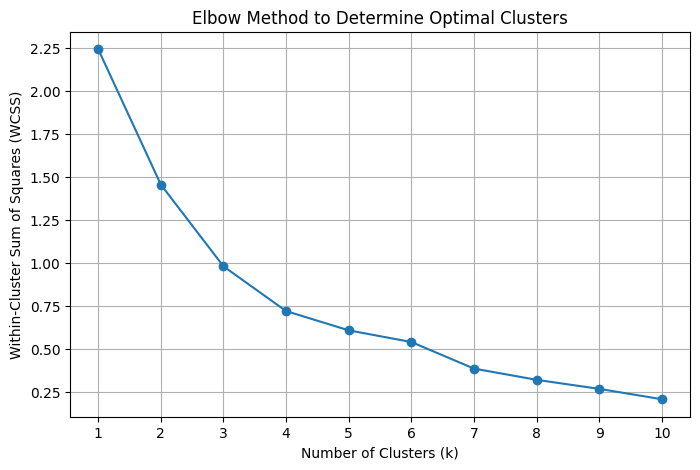

In [244]:
# Load data
#file_path = "DGCD-129_using_graphml.csv"  # Replace with your file path
file_path = "DGCD-129_using_node_txt.csv"  # Replace with your file path

#check_for_file(file_path)
#data = pd.read_excel(file_path, index_col=0)  # First column is used as the index
#data = pd.read_csv(file_path, index_col=0)  # First column is used as the index

# Step 2: Convert the distance matrix to feature space using MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, metric=True)
features = mds.fit_transform(data.values)

# Step 3: Apply K-Means clustering and use the elbow method
wcss = []
max_clusters = 10  # Adjust this based on dataset size

for k in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

# Step 4: Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_clusters + 1), wcss, marker='o')
plt.title("Elbow Method to Determine Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(range(1, max_clusters + 1))
plt.grid()
plt.show()

In [134]:

# Step 5: Choose the optimal number of clusters (k) and fit K-Means
optimal_k = int(input("Enter the optimal number of clusters (k) based on the elbow plot: "))
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(features)

# Step 6: Analyze Results
print("Cluster Labels for Each Point:")
print(labels)

# Optional: Save results
data['Cluster'] = labels
"""
file_pathx="clustered_" + str(optimal_k) + "_" + file_path
data.to_excel(file_pathx)"""
file_pathx = "clustered_" + str(optimal_k) + "_" + file_path.replace(".csv", ".xlsx")
data.to_excel(file_pathx, index=False)


Enter the optimal number of clusters (k) based on the elbow plot: 5
Cluster Labels for Each Point:
[1 2 1 1 1 1 4 4 4 0 4 4 1 1 4 4 0 3 4 1 2 1 4 1 4 0 1 2 1 1 1 1 4 1]


In [135]:
data["Cluster"].sort_values()

,Cluster
IA_Dorn_Vorsicht_S,0
_Heckmann_Das_He,0
IA_Mann_Der_Geburt,0
IA_Aichinger_Das_F,1
_Bobrowski_Brief,1
IA_Grimm_Frau_Holl,1
_Bachmann_Arkadi,1
IA_Auerbach_Der_Ki,1
IA_Kafka_Der_neue_,1
_Reventlow_Der_f,1


#Silhouette Analysis in K-means Clustering

In [245]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Load data from Excel file
#file_path = "DGCD-129_using_graphml.csv"  # Replace with your file path
file_path = "DGCD-129_using_node_txt.csv"  # Replace with your file path


In [246]:
#df = pd.read_csv(file_path, index_col=0)
df = average_df
# Check the data
df.head()

,Aichinger_Das_Fenstertheater.txt_split_network.graphml,Altenberg_Die_Natur.txt_split_network.graphml,Auerbach_Der_Kindesmord.txt_split_network.graphml,Bachmann_Arkadien_clean_neu.txt_split_network.graphml,Bierbaum_Der_Mohr.txt_split_network.graphml,Bobrowski_Brief_aus_Amerika.txt_split_network.graphml,Brecht_Herr_Keuner_und_die_Schauspielerin.txt_split_network.graphml,Brecht_Müllers_natürliche_Haltung.txt_split_network.graphml,Böll_Wanderer_kommst_du_nach_Spa_clean.txt_split_network.graphml,Dorn_Vorsicht_Steinschlag.txt_split_network.graphml,...,Löns_Die_beiden_Höfe_clean.txt_split_network.graphml,Mann_Der_Geburtstag_der_Frau_Baronin.txt_split_network.graphml,Reventlow_Der_feine_Dieb.txt_split_network.graphml,Roth_Der_stumme_Prophet_Fragment_gb_clean_neu.txt_split_network.graphml,Stamm_Das_schönste_Mädchen.txt_split_network.graphml,Storm_Im_Saal.txt_split_network.graphml,Tucholsky_Märchen.txt_split_network.graphml,Walser_Der_Nachen.txt_split_network.graphml,Wendt_Tote_Vögel.txt_split_network.graphml,Wolf_Der_Stern_der_Schönheit.txt_split_network.graphml
IA_Aichinger_Das_F,0.000000,0.302128,0.358248,0.356396,0.328841,0.217059,0.360523,0.434683,0.452912,0.533924,...,0.378243,0.400497,0.306857,0.375509,0.265838,0.315281,0.303711,0.342028,0.393220,0.347685
_Altenberg_Die_N,0.302128,0.000000,0.397095,0.392256,0.290457,0.285230,0.408266,0.501283,0.439167,0.528664,...,0.411890,0.426145,0.308087,0.304166,0.262970,0.383420,0.310072,0.357341,0.368328,0.420055
IA_Auerbach_Der_Ki,0.358248,0.397095,0.000000,0.367101,0.306861,0.324188,0.301862,0.331990,0.405172,0.509448,...,0.365691,0.425809,0.338103,0.284861,0.290516,0.367200,0.348625,0.356025,0.334539,0.326895
_Bachmann_Arkadi,0.356396,0.392256,0.367101,0.000000,0.316928,0.308989,0.305298,0.344456,0.402857,0.479160,...,0.375809,0.321930,0.315821,0.410696,0.254098,0.343669,0.343137,0.370800,0.344267,0.362123
IA_Bierbaum_Der_Mo,0.328841,0.290457,0.306861,0.316928,0.000000,0.255677,0.320612,0.328115,0.345299,0.488827,...,0.352287,0.377328,0.245625,0.398126,0.250392,0.236529,0.323426,0.320068,0.247383,0.316088


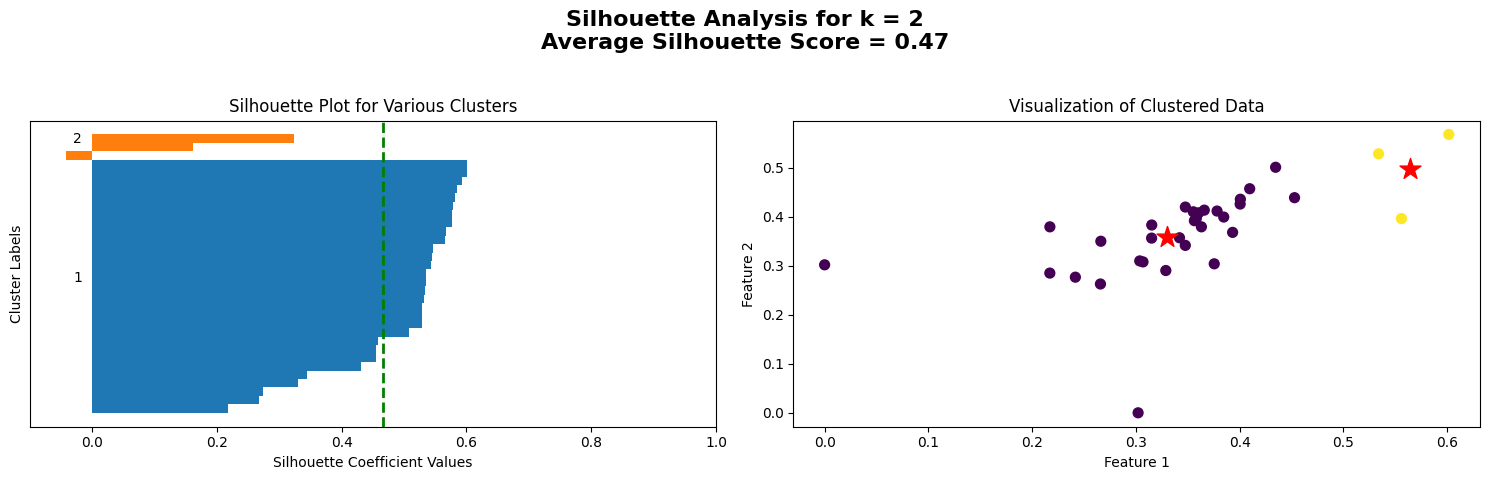

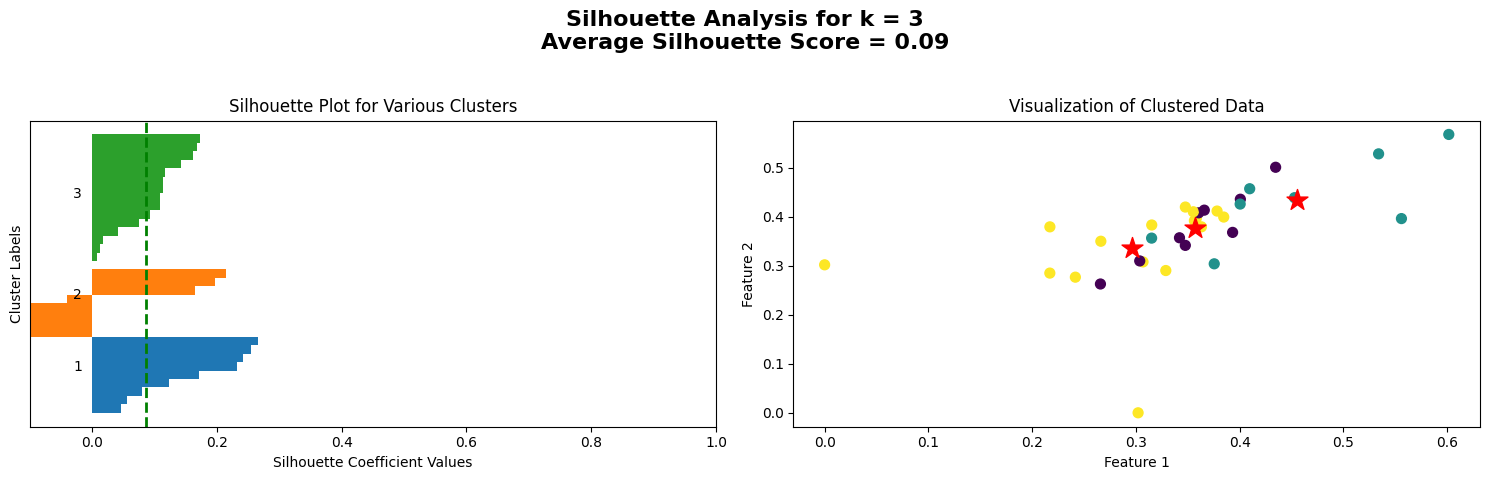

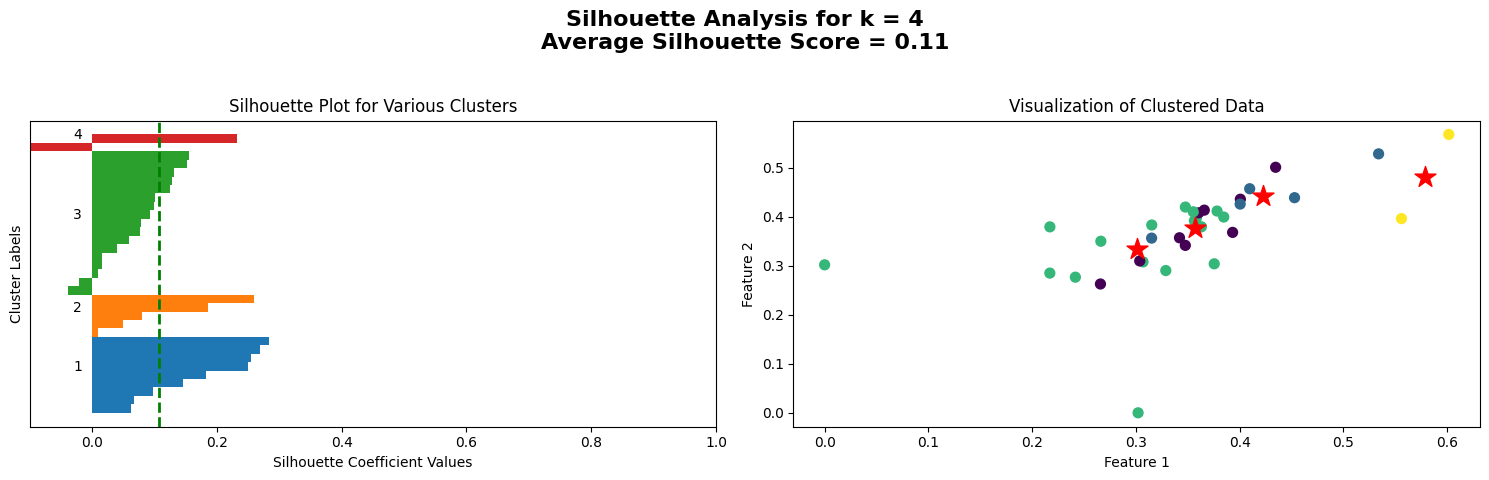

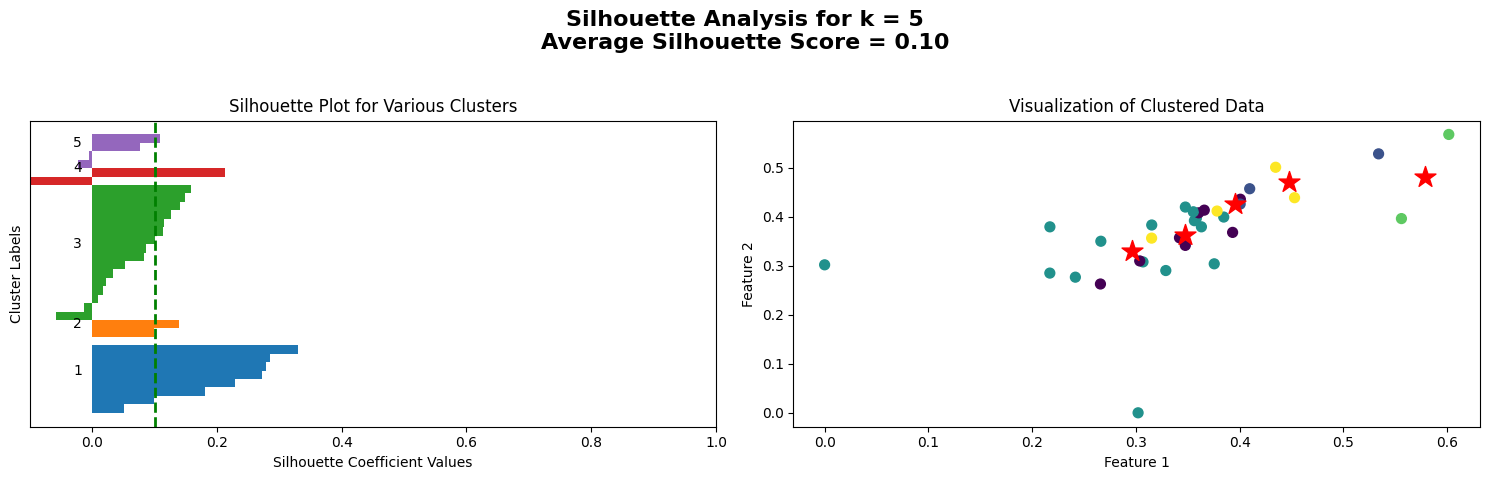

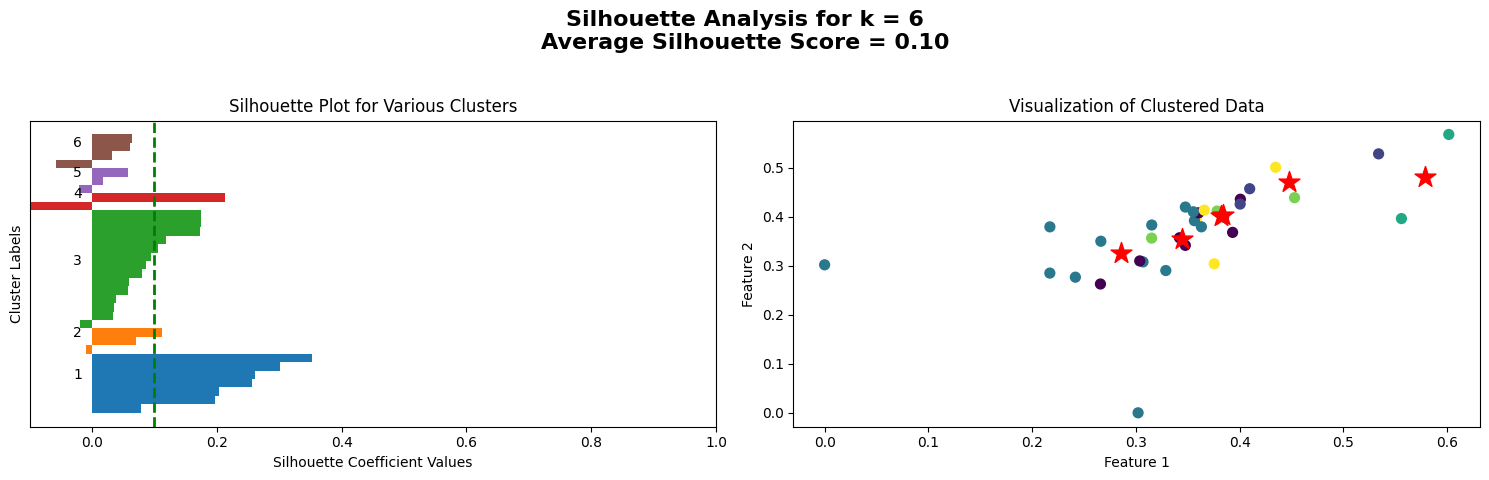

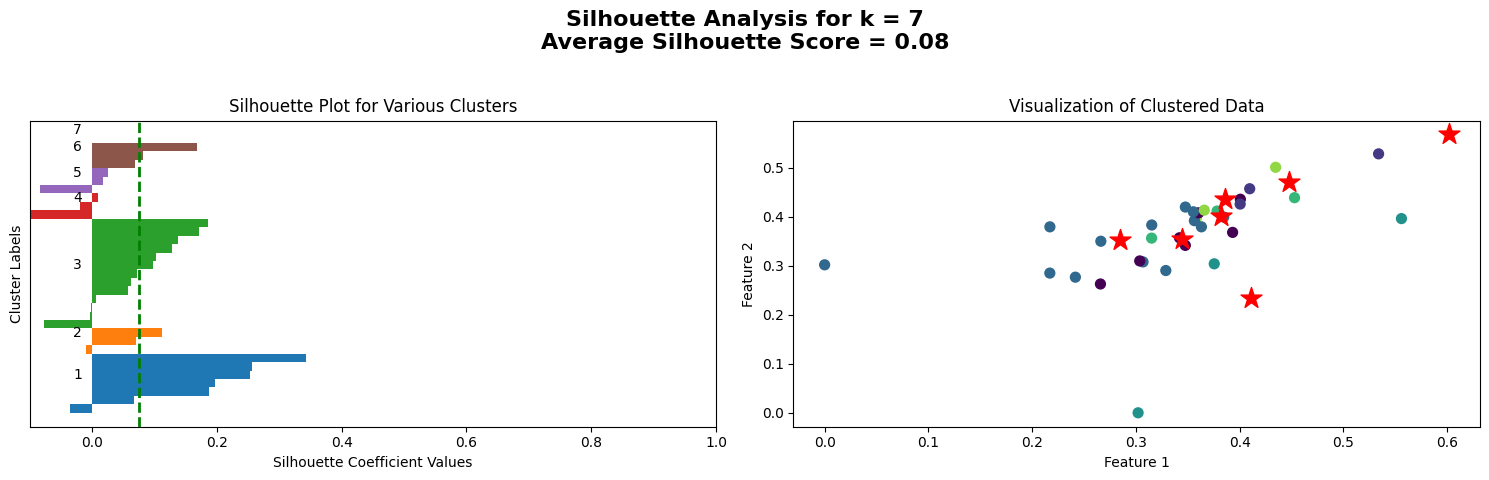

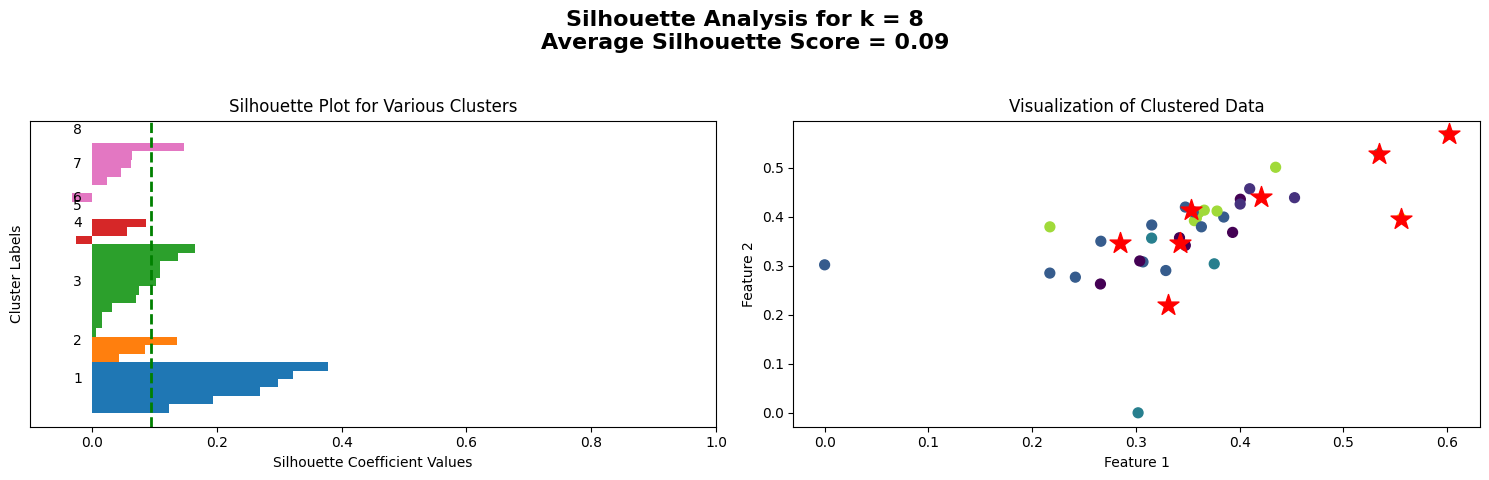

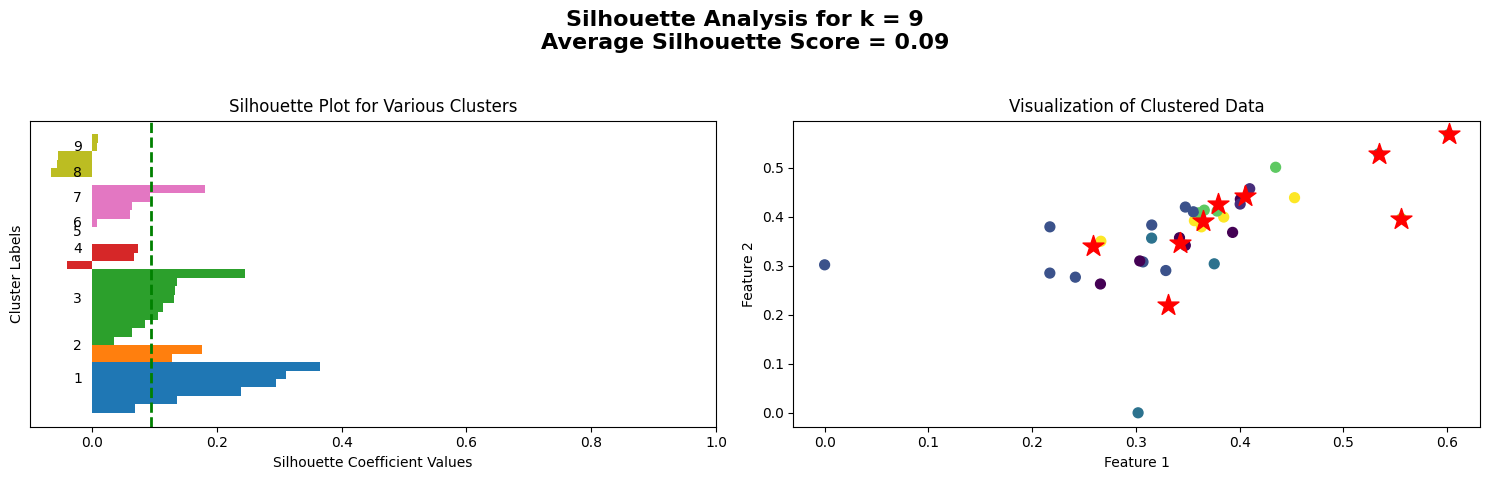

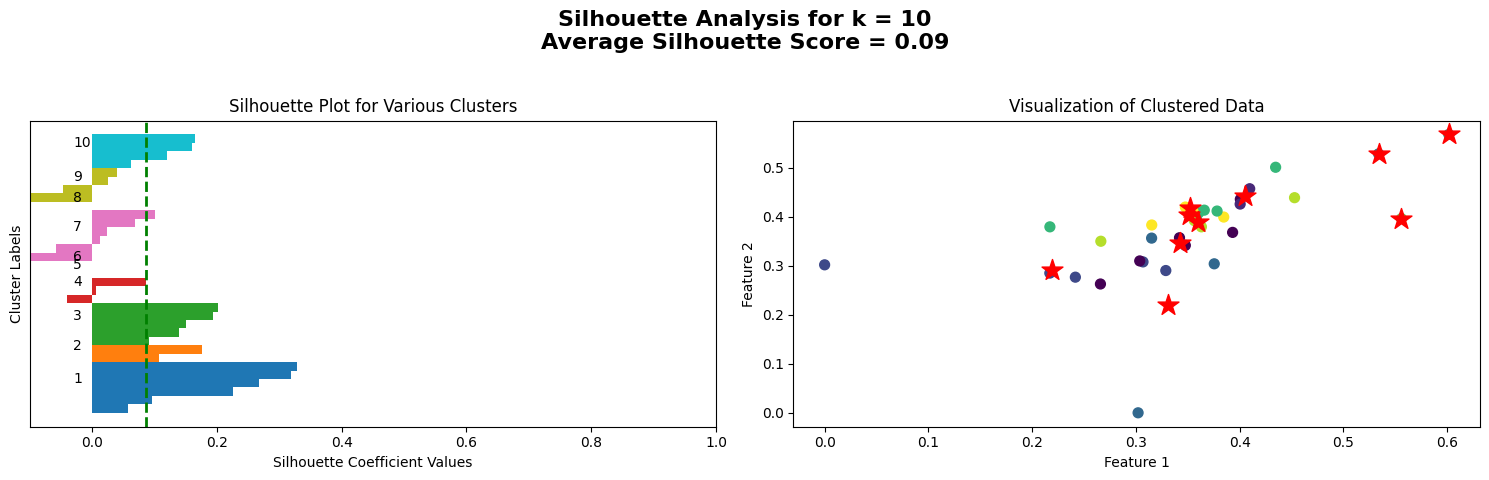

In [247]:


# Use the matrix directly for clustering
data = df.values  # Convert DataFrame to numpy array

# Silhouette analysis for various numbers of clusters
for k in [2, 3, 4, 5 , 6 , 7 ,8 ,9, 10]:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Run the KMeans algorithm
    km = KMeans(n_clusters=k, random_state=42)
    y_predict = km.fit_predict(data)
    centroids = km.cluster_centers_

    # Calculate silhouette scores
    silhouette_vals = silhouette_samples(data, y_predict)
    avg_score = silhouette_score(data, y_predict)

    # Silhouette plot
    y_lower, y_upper = 0, 0
    for i, cluster in enumerate(np.unique(y_predict)):
        cluster_silhouette_vals = silhouette_vals[y_predict == cluster]
        cluster_silhouette_vals.sort()
        y_upper += len(cluster_silhouette_vals)
        ax[0].barh(range(y_lower, y_upper), cluster_silhouette_vals, height=1)
        ax[0].text(-0.03, (y_lower + y_upper) / 2, str(i + 1))
        y_lower += len(cluster_silhouette_vals)

    ax[0].axvline(avg_score, linestyle='--', linewidth=2, color='green')
    ax[0].set_yticks([])
    ax[0].set_xlim([-0.1, 1])
    ax[0].set_xlabel('Silhouette Coefficient Values')
    ax[0].set_ylabel('Cluster Labels')
    ax[0].set_title('Silhouette Plot for Various Clusters')

    # Scatter plot of clustered data
    ax[1].scatter(data[:, 0], data[:, 1], c=y_predict, cmap='viridis', s=50)
    ax[1].scatter(centroids[:, 0], centroids[:, 1], marker='*', c='red', s=250)
    ax[1].set_xlabel('Feature 1')
    ax[1].set_ylabel('Feature 2')
    ax[1].set_title('Visualization of Clustered Data')

    # Add a super title for the entire figure
    plt.suptitle(f'Silhouette Analysis for k = {k}\nAverage Silhouette Score = {avg_score:.2f}',
                 fontsize=16, fontweight='semibold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for the suptitle
    plt.savefig(f'Silhouette_analysis_k{k}.jpg')
    plt.show()


# hierarchical clustering and Optimal Leaf Ordering

In [139]:
average_df = average_df.iloc[:, :-1] # drop last col

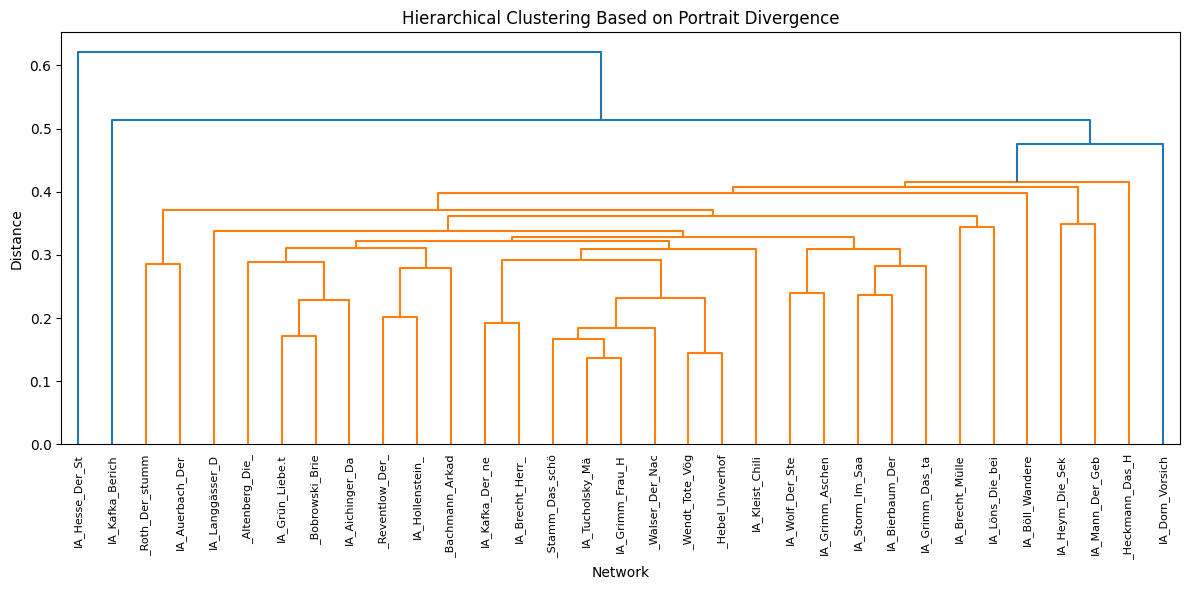

In [248]:
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

#data = pd.read_csv(file_path, index_col=0)  # First column is used as the index

labels = average_df.index.str[:15].tolist()

# Assume `dist_matrix` is your DGCD-129 distance matrix (numpy array or DataFrame)

dist_matrix = average_df.values
condensed_dist = squareform(dist_matrix)  # convert to condensed format

Z = linkage(condensed_dist, method='average')  # average linkage for distances, alternative "complete"

Z_olo = optimal_leaf_ordering(Z, condensed_dist)  # reorder leaves

plt.figure(figsize=(12, 6))
dendrogram(Z_olo, labels=labels, leaf_rotation=90)
plt.title("Hierarchical Clustering Based on Portrait Divergence")
plt.xlabel("Network")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [126]:
print(data.shape)  # Should be (n, n)


(33, 33)


In [101]:
average_df.head()

,Aichinger_Das_Fenstertheater.txt_split_network.graphml,Altenberg_Die_Natur.txt_split_network.graphml,Auerbach_Der_Kindesmord.txt_split_network.graphml,Bachmann_Arkadien_clean_neu.txt_split_network.graphml,Bierbaum_Der_Mohr.txt_split_network.graphml,Bobrowski_Brief_aus_Amerika.txt_split_network.graphml,Brecht_Herr_Keuner_und_die_Schauspielerin.txt_split_network.graphml,Brecht_Müllers_natürliche_Haltung.txt_split_network.graphml,Böll_Wanderer_kommst_du_nach_Spa_clean.txt_split_network.graphml,Dorn_Vorsicht_Steinschlag.txt_split_network.graphml,...,Mann_Der_Geburtstag_der_Frau_Baronin.txt_split_network.graphml,Reventlow_Der_feine_Dieb.txt_split_network.graphml,Roth_Der_stumme_Prophet_Fragment_gb_clean_neu.txt_split_network.graphml,Stamm_Das_schönste_Mädchen.txt_split_network.graphml,Storm_Im_Saal.txt_split_network.graphml,Tucholsky_Märchen.txt_split_network.graphml,Walser_Der_Nachen.txt_split_network.graphml,Wendt_Tote_Vögel.txt_split_network.graphml,Wolf_Der_Stern_der_Schönheit.txt_split_network.graphml,Cluster
CLEAR_Aichinger_Das_F,0.000000,0.302128,0.358248,0.356396,0.328841,0.217059,0.360523,0.434683,0.452912,0.533924,...,0.400497,0.306857,0.375509,0.265838,0.315281,0.303711,0.342028,0.393220,0.347685,2
UNCLEAR_Altenberg_Die_N,0.302128,0.000000,0.397095,0.392256,0.290457,0.285230,0.408266,0.501283,0.439167,0.528664,...,0.426145,0.308087,0.304166,0.262970,0.383420,0.310072,0.357341,0.368328,0.420055,2
CLEAR_Auerbach_Der_Ki,0.358248,0.397095,0.000000,0.367101,0.306861,0.324188,0.301862,0.331990,0.405172,0.509448,...,0.425809,0.338103,0.284861,0.290516,0.367200,0.348625,0.356025,0.334539,0.326895,0
UNCLEAR_Bachmann_Arkadi,0.356396,0.392256,0.367101,0.000000,0.316928,0.308989,0.305298,0.344456,0.402857,0.479160,...,0.321930,0.315821,0.410696,0.254098,0.343669,0.343137,0.370800,0.344267,0.362123,1
CLEAR_Bierbaum_Der_Mo,0.328841,0.290457,0.306861,0.316928,0.000000,0.255677,0.320612,0.328115,0.345299,0.488827,...,0.377328,0.245625,0.398126,0.250392,0.236529,0.323426,0.320068,0.247383,0.316088,1


# agglomerative clustering

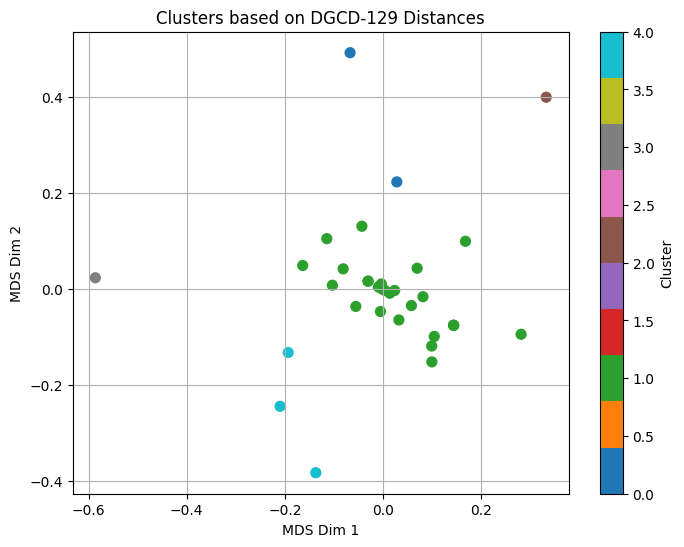

In [219]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=optimal_k, metric='precomputed', linkage='average')
labels = agg.fit_predict(data)

plt.figure(figsize=(8, 6))
plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='tab10', s=50)
plt.title("Clusters based on DGCD-129 Distances")
plt.xlabel("MDS Dim 1")
plt.ylabel("MDS Dim 2")
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()


In [220]:
# Get names from the index
names = data.index

# Print each name with its assigned cluster
for name, label in zip(names, labels):
    print(f"{name} --> Cluster {label}")


AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [ ]:
# Create a new DataFrame with names and cluster labels
results_df = pd.DataFrame({'Network': names, 'Cluster': labels})

# Save to Excel
results_df.to_excel("clustered_networks.xlsx", index=False)


# F-Score

In [249]:
from sklearn.metrics import silhouette_score

best_k = None
best_score = -1

for k in range(2, 10):
    labels = fcluster(Z_olo, k, criterion='maxclust')
    score = silhouette_score(dist_matrix, labels, metric='precomputed')  # since you're using distances
    if score > best_score:
        best_k = k
        best_score = score


In [250]:
print(best_k)
print(best_score)

2
0.40036000815373246


In [251]:
# Step 1: Extract true labels from average_df.index
true_labels = [
    name.split('_')[0] if name.startswith('IA_') else ""
    for name in average_df.index
]


In [252]:
from scipy.cluster.hierarchy import fcluster

# Choose the number of clusters, e.g., 2
n_clusters = 2
cluster_labels = fcluster(Z_olo, n_clusters, criterion='maxclust')


In [253]:
import pandas as pd
from collections import Counter

# Create DataFrame linking each text to its cluster and true class
df_clustered = pd.DataFrame({
    'cluster': cluster_labels,
    'true_class': true_labels  # Must be aligned with average_df.index
}, index=average_df.index)

# Assign predicted class to each cluster based on majority vote
cluster_to_class = (
    df_clustered.groupby('cluster')['true_class']
    .agg(lambda x: Counter(x).most_common(1)[0][0])
)

# Map predicted class back to each row
df_clustered['predicted_class'] = df_clustered['cluster'].map(cluster_to_class)


In [254]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df_clustered['true_class']
y_pred = df_clustered['predicted_class']

# Since "" is one of the classes, treat it as a valid label
labels = ["IA", ""]  # Define the order explicitly

precision = precision_score(y_true, y_pred, labels=labels, average='macro')
recall = recall_score(y_true, y_pred, labels=labels, average='macro')
f1 = f1_score(y_true, y_pred, labels=labels, average='macro')

print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")
print(f"F1 Score (macro): {f1:.3f}")


Precision (macro): 0.348
Recall (macro): 0.500
F1 Score (macro): 0.411


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


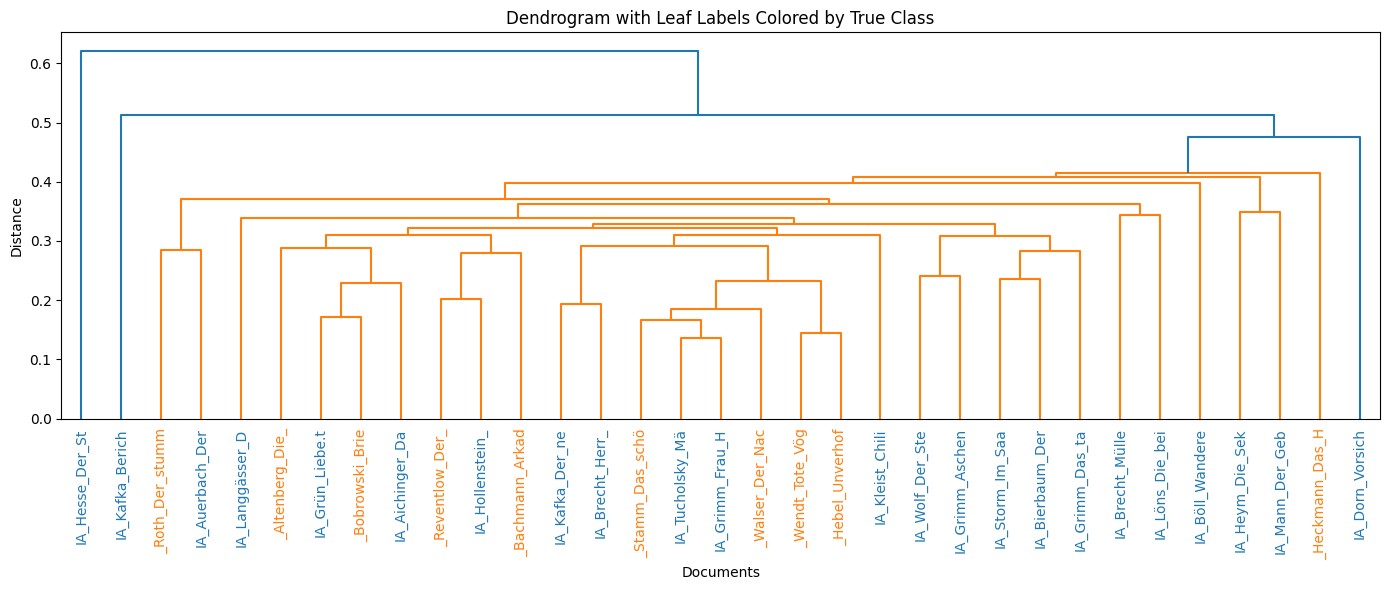

In [255]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

# Define color map for true classes
label_colors = {
    "IA": "tab:blue",
    "": "tab:orange"
}

# Extract labels and colors
true_labels = [name.split('_')[0] if name.startswith('IA_') else "" for name in average_df.index]
labels = average_df.index.str[:15].tolist()
colors = [label_colors[label] for label in true_labels]

# Plot dendrogram with colored leaf labels
plt.figure(figsize=(14, 6))
dend = dendrogram(Z_olo, labels=labels, leaf_rotation=90, leaf_font_size=10)

# Color the leaf labels
ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl, color in zip(xlbls, [colors[i] for i in dend['leaves']]):
    lbl.set_color(color)

plt.title("Dendrogram with Leaf Labels Colored by True Class")
plt.xlabel("Documents")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


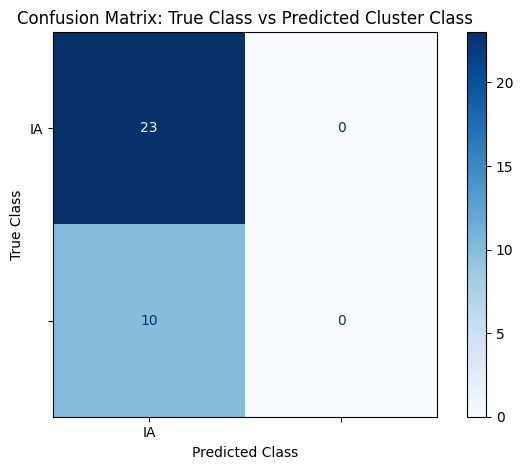

In [256]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get ground truth and predictions
y_true = df_clustered['true_class']
y_pred = df_clustered['predicted_class']

# Define label order explicitly (important since "" is valid class)
labels = ["IA", ""]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: True Class vs Predicted Cluster Class")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


In [222]:
from scipy.cluster.hierarchy import linkage, fcluster, optimal_leaf_ordering
from scipy.spatial.distance import squareform
from sklearn.metrics import f1_score
from collections import Counter
import numpy as np
import pandas as pd

# Your precomputed symmetric distance matrix
dist_matrix = average_df.values
condensed_dist = squareform(dist_matrix)

# Linkage methods to try
linkage_methods = ['average', 'complete', 'single']  # 'ward' not allowed for precomputed

# Range of cluster numbers
k_range = range(2, 6)

# Store best results
best_config = {'f1': -1}

# Results storage (optional)
results = []

for method in linkage_methods:
    try:
        Z = linkage(condensed_dist, method=method)
        Z_olo = optimal_leaf_ordering(Z, condensed_dist)
    except Exception as e:
        print(f"Error with linkage method '{method}': {e}")
        continue

    for k in k_range:
        cluster_labels = fcluster(Z_olo, k, criterion='maxclust')

        # Map each cluster to most common class
        df_k = pd.DataFrame({
            'true_class': true_labels,
            'cluster': cluster_labels
        })

        cluster_to_class = (
            df_k.groupby('cluster')['true_class']
            .agg(lambda x: Counter(x).most_common(1)[0][0])
        )

        df_k['predicted_class'] = df_k['cluster'].map(cluster_to_class)

        # Compute macro F1 (to balance IA vs "")
        f1 = f1_score(df_k['true_class'], df_k['predicted_class'], average='macro', zero_division=0)

        results.append({
            'linkage': method,
            'k': k,
            'f1_macro': f1
        })

        if f1 > best_config['f1']:
            best_config = {
                'f1': f1,
                'k': k,
                'linkage': method,
                'cluster_labels': cluster_labels,
                'predicted_class': df_k['predicted_class'],
                'true_class': df_k['true_class']
            }

print(f"\n✅ Best config: linkage='{best_config['linkage']}', k={best_config['k']}, F1-macro={best_config['f1']:.3f}")



✅ Best config: linkage='average', k=5, F1-macro=0.591


In [214]:
print(average_df.shape[0])
print(len(true_labels))


34
1


# Three dimensional vector for each network

In [33]:
import pandas as pd

# Replace these with your actual filenames
df1 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_Relationen_18Jun2025.xlsx', index_col=0)
df2 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_Wertungen_abs_negative_18Jun2025.xlsx', index_col=0)
df3 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_Wertungen_positive_18Jun2025.xlsx', index_col=0)
df4 = pd.read_excel('portrait_divergence_matrix_split_network_graphml_pos_u_neg_Wertungen_17Jun2025.xlsx', index_col=0)

In [34]:
# Drop rows where all elements are NaN
df1 = df1.dropna(how='all')
# Drop columns where all elements are NaN
df1 = df1.dropna(axis=1, how='all')

# Drop rows where all elements are NaN
df2 = df2.dropna(how='all')
# Drop columns where all elements are NaN
df2 = df2.dropna(axis=1, how='all')

# Drop rows where all elements are NaN
df3 = df3.dropna(how='all')
# Drop columns where all elements are NaN
df3 = df3.dropna(axis=1, how='all')


Found 33 common networks
Tensor shape: (33, 33, 3)

Clustering results:
                                          network  cluster
0                    Aichinger_Das_Fenstertheater        0
1                             Altenberg_Die_Natur        0
2                         Auerbach_Der_Kindesmord        0
3                     Bachmann_Arkadien_clean_neu        0
4                               Bierbaum_Der_Mohr        0
5                     Bobrowski_Brief_aus_Amerika        0
6       Brecht_Herr_Keuner_und_die_Schauspielerin        0
7               Brecht_Müllers_natürliche_Haltung        0
8          Böll_Wanderer_kommst_du_nach_Spa_clean        0
9                       Dorn_Vorsicht_Steinschlag        1
10                       Grimm_Aschenputtel_clean        0
11                Grimm_Das_tapfere_Schneiderlein        0
12                     Grimm_Frau_Holle_clean_neu        0
13                                     Grün_Liebe        0
14                 Hebel_Unverhofftes_Wiede

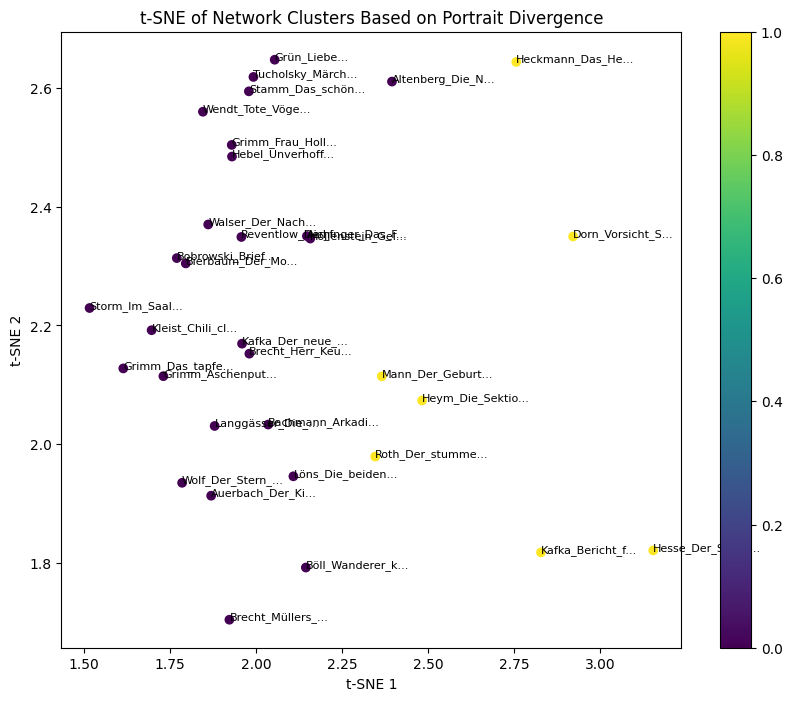

In [36]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Extract base names (before .txt) for matching
def extract_base_name(full_name):
    return full_name.split('.txt')[0]

# Get common networks across all dataframes
common_networks = sorted(list(
    set(extract_base_name(name) for name in df1.columns) &
    set(extract_base_name(name) for name in df2.columns) &
    set(extract_base_name(name) for name in df3.columns)
))

print(f"Found {len(common_networks)} common networks")

# Align all dataframes to the same network order
def align_df(df, base_names):
    """Reorder rows/cols to match base_names order, extracting original names"""
    orig_names = [next(name for name in df.columns if extract_base_name(name) == bn) for bn in base_names]
    return df.loc[orig_names, orig_names]

df1_aligned = align_df(df1, common_networks)
df2_aligned = align_df(df2, common_networks)
df3_aligned = align_df(df3, common_networks)

# Create 3D tensor (33 x 33 x 3)
tensor = np.stack([
    df1_aligned.values,
    df2_aligned.values,
    df3_aligned.values
], axis=-1)

print("Tensor shape:", tensor.shape)  # Should be (33, 33, 3)

# Flatten into feature vectors (33 x (33*3))
# Each network is represented by its divergences to all others across 3 aspects
features = tensor.reshape(len(common_networks), -1)  # shape (33, 99)

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Cluster (adjust n_clusters as needed)
n_clusters = 2  # Example - choose based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

# Results
results = pd.DataFrame({
    'network': common_networks,
    'cluster': clusters
})

print("\nClustering results:")
print(results)

# Optional: Dimensionality reduction for visualization
if len(common_networks) > 2:
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt

    # Reduce to 2D for visualization
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features_scaled)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clusters, cmap='viridis')
    plt.colorbar(scatter)

    # Label some points
    for i, name in enumerate(common_networks):
        if i % 1 == 0:  # Label every 3rd network
            plt.text(features_2d[i, 0], features_2d[i, 1], name[:15]+"...", fontsize=8)

    plt.title("t-SNE of Network Clusters Based on Portrait Divergence")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.savefig('tsne_portrait_divergence.png', dpi=1000, facecolor='white')
    plt.show()

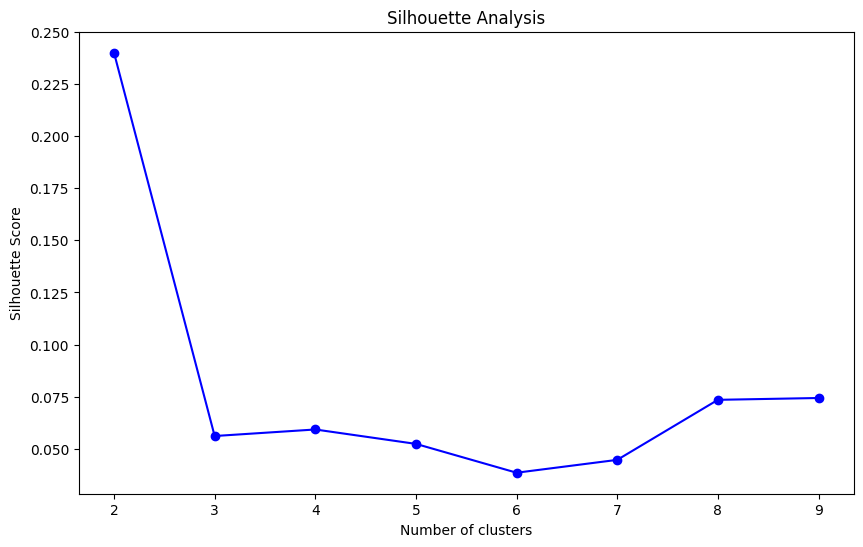

In [46]:
from sklearn.metrics import silhouette_score

max_clusters = 9

silhouette_scores = []
for k in range(2, max_clusters+1):  # Silhouette requires k >= 2
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, preds)
    silhouette_scores.append(score)

plt.figure(figsize=(10,6))
plt.plot(range(2, max_clusters+1), silhouette_scores, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

In [37]:
# get labels

# Step 1: Clean both indexes by stripping '_split_network.graphml'
df1.index = df1.index.astype(str).str.split('.txt').str[0]
df_assertion['Document_title'] = df_assertion['Document_title'].astype(str).str.split('.txt').str[0]

# Step 2: Create a mapping from cleaned Document_title to assertive_clarity_cat
mapping_series = df_assertion.set_index('Document_title')['assertive_force_cat']
#mapping_series = df_assertion.set_index('Document_title')['implicit_assertion_cat']
#mapping_series = df_assertion.set_index('Document_title')['assertive_clarity_cat']


# Step 3: Create new index by combining assertive_clarity_cat + first 15 chars of filename
new_index = []
for fname in df1.index:
    cat = mapping_series.get(fname, "UNKNOWN")  # fallback if not found
    new_name = f"{cat}_{fname[:15]}"
    new_index.append(new_name)

# Step 4: Assign new index to average_df
df1.index = new_index


In [38]:
true_labels_df = mapping_series
true_labels_df

,assertive_force_cat
Document_title,
Aichinger_Das_Fenstertheater,IA
Altenberg_Die_Natur,NO-IA
Auerbach_Der_Kindesmord,IA
Bachmann_Arkadien_clean_neu,NO-IA
Bierbaum_Der_Mohr,IA
Bobrowski_Brief_aus_Amerika,NO-IA
Böll_Wanderer_kommst_du_nach_Spa_clean,IA
Brecht_Herr_Keuner_und_die_Schauspielerin,IA
Brecht_Müllers_natürliche_Haltung,IA



Per-class metrics:
- NO-IA (0): Precision = 0.000, Recall = 0.000, F1 = 0.000
- IA (1):    Precision = 0.697, Recall = 1.000, F1 = 0.821

Macro F1:    0.411
Weighted F1: 0.573

Classification Report:
              precision    recall  f1-score   support

       NO-IA       0.00      0.00      0.00        10
          IA       0.70      1.00      0.82        23

    accuracy                           0.70        33
   macro avg       0.35      0.50      0.41        33
weighted avg       0.49      0.70      0.57        33


Missing networks analysis:
- In true labels but not in clustering results: 2
  Examples: ['Mann_Beim_Propheten_clean', 'Franck_Streuselschnecke']
- In clustering results but not in true labels: 0


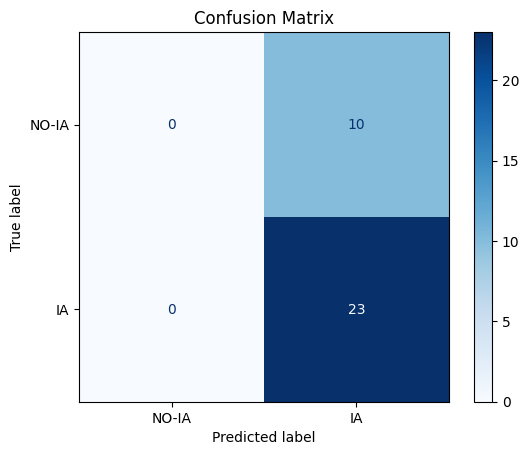

In [39]:
import pandas as pd

import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,  # <-- Add this import
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Assuming:
# - results_df (from clustering) has columns: 'network' and 'cluster'
# - true_labels_df has index 'Document_title' and column 'assertive_force_cat'

# 1. Prepare the dataframes
# Create base_name columns in both dataframes
results_df = results.copy()  # Make sure we're working with a DataFrame
results_df['base_name'] = results_df['network'].apply(lambda x: x.split('.txt')[0] if '.txt' in x else x)

# Reset index on true_labels_df to make Document_title a column
true_labels_df = true_labels_df.reset_index()
true_labels_df['base_name'] = true_labels_df['Document_title'].apply(lambda x: x.split('.txt')[0] if '.txt' in x else x)

# 2. Merge the dataframes
merged = pd.merge(results_df, true_labels_df,
                 on='base_name',
                 how='inner')

if len(merged) == 0:
    raise ValueError("No matching networks found between clustering results and true labels")

# 3. Label clusters by majority vote
cluster_labels = {}
for cluster in merged['cluster'].unique():
    cluster_df = merged[merged['cluster'] == cluster]
    majority = cluster_df['assertive_force_cat'].mode()[0]  # Get most frequent label
    cluster_labels[cluster] = majority

# 4. Assign predicted labels
merged['predicted_label'] = merged['cluster'].map(cluster_labels)

# 5. Calculate extended metrics
# Convert labels to binary (if not already done)
label_map = {'IA': 1, 'NO-IA': 0}
merged['true_binary'] = merged['assertive_force_cat'].map(label_map)
merged['predicted_binary'] = merged['predicted_label'].map(label_map)

# Individual class precision/recall/F1
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    merged['true_binary'],
    merged['predicted_binary'],
    labels=[0, 1]  # NO-IA (0), IA (1)
)

# Macro F1 (unweighted mean across classes)
macro_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='macro'
)

# Weighted F1 (weighted by support)
weighted_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='weighted'
)

# Print results
print("\nPer-class metrics:")
print(f"- NO-IA (0): Precision = {precision_per_class[0]:.3f}, Recall = {recall_per_class[0]:.3f}, F1 = {f1_per_class[0]:.3f}")
print(f"- IA (1):    Precision = {precision_per_class[1]:.3f}, Recall = {recall_per_class[1]:.3f}, F1 = {f1_per_class[1]:.3f}")
print(f"\nMacro F1:    {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

# Alternative: Full classification report (includes all metrics)
print("\nClassification Report:")
print(classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['NO-IA', 'IA']
))

# 6. Show missing networks (optional)
missing_in_results = set(true_labels_df['base_name']) - set(results_df['base_name'])
missing_in_labels = set(results_df['base_name']) - set(true_labels_df['base_name'])

print("\nMissing networks analysis:")
print(f"- In true labels but not in clustering results: {len(missing_in_results)}")
if missing_in_results:
    print("  Examples:", list(missing_in_results)[:3])
print(f"- In clustering results but not in true labels: {len(missing_in_labels)}")
if missing_in_labels:
    print("  Examples:", list(missing_in_labels)[:3])

# 7. Confusion matrix (optional)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(merged['true_binary'], merged['predicted_binary'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['NO-IA', 'IA'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [41]:
# Generate the classification report as a string
report_str = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['NO-IA', 'IA'],
    output_dict=False  # This returns a string
)

# Convert the string report to a dictionary (which pandas can easily convert to DataFrame)
report_dict = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['NO-IA', 'IA'],
    output_dict=True  # This returns a dictionary
)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save to Excel
report_df.to_excel("portrait_classification_report_force.xlsx")

print("Classification report saved to 'classification_report.xlsx'")

Classification report saved to 'classification_report.xlsx'


In [149]:
results_df

,network,cluster,base_name
0,Aichinger_Das_Fenstertheater,0,Aichinger_Das_Fenstertheater
1,Altenberg_Die_Natur,0,Altenberg_Die_Natur
2,Auerbach_Der_Kindesmord,0,Auerbach_Der_Kindesmord
3,Bachmann_Arkadien_clean_neu,0,Bachmann_Arkadien_clean_neu
4,Bierbaum_Der_Mohr,0,Bierbaum_Der_Mohr
5,Bobrowski_Brief_aus_Amerika,0,Bobrowski_Brief_aus_Amerika
6,Brecht_Herr_Keuner_und_die_Schauspielerin,0,Brecht_Herr_Keuner_und_die_Schauspielerin
7,Brecht_Müllers_natürliche_Haltung,0,Brecht_Müllers_natürliche_Haltung
8,Böll_Wanderer_kommst_du_nach_Spa_clean,0,Böll_Wanderer_kommst_du_nach_Spa_clean
9,Dorn_Vorsicht_Steinschlag,1,Dorn_Vorsicht_Steinschlag


In [135]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(merged['assertive_force_cat'], merged['cluster'])
#ari = adjusted_rand_score(merged['assertive_clarity_cat'], merged['cluster'])

print(f"Adjusted Rand Index: {ari:.3f}")
# Interpretation: 1=perfect match, 0=random, negative=worse than random

Adjusted Rand Index: 0.092


In [148]:
merged

,network,cluster,base_name,level_0,index,Document_title,assertive_clarity_cat,predicted_label,true_binary,predicted_binary
0,Aichinger_Das_Fenstertheater,0,Aichinger_Das_Fenstertheater,0,0,Aichinger_Das_Fenstertheater,IA,IA,1,1
1,Altenberg_Die_Natur,0,Altenberg_Die_Natur,1,1,Altenberg_Die_Natur,NO-IA,IA,0,1
2,Auerbach_Der_Kindesmord,0,Auerbach_Der_Kindesmord,2,2,Auerbach_Der_Kindesmord,IA,IA,1,1
3,Bachmann_Arkadien_clean_neu,0,Bachmann_Arkadien_clean_neu,3,3,Bachmann_Arkadien_clean_neu,NO-IA,IA,0,1
4,Bierbaum_Der_Mohr,0,Bierbaum_Der_Mohr,4,4,Bierbaum_Der_Mohr,IA,IA,1,1
5,Bobrowski_Brief_aus_Amerika,0,Bobrowski_Brief_aus_Amerika,5,5,Bobrowski_Brief_aus_Amerika,NO-IA,IA,0,1
6,Brecht_Herr_Keuner_und_die_Schauspielerin,0,Brecht_Herr_Keuner_und_die_Schauspielerin,7,7,Brecht_Herr_Keuner_und_die_Schauspielerin,IA,IA,1,1
7,Brecht_Müllers_natürliche_Haltung,0,Brecht_Müllers_natürliche_Haltung,8,8,Brecht_Müllers_natürliche_Haltung,NO-IA,IA,0,1
8,Böll_Wanderer_kommst_du_nach_Spa_clean,0,Böll_Wanderer_kommst_du_nach_Spa_clean,6,6,Böll_Wanderer_kommst_du_nach_Spa_clean,IA,IA,1,1
9,Dorn_Vorsicht_Steinschlag,1,Dorn_Vorsicht_Steinschlag,9,9,Dorn_Vorsicht_Steinschlag,NO-IA,NO-IA,0,0


In [150]:
# Count predicted labels per cluster
predicted_counts = merged.groupby('cluster')['predicted_label'].value_counts().unstack(fill_value=0)

print("Predicted counts per cluster:")
print(predicted_counts)

Predicted counts per cluster:
predicted_label  IA  NO-IA
cluster                   
0                26      0
1                 0      7


In [153]:
# Count true labels per cluster
true_label_counts = merged.groupby('cluster')['true_binary'].value_counts().unstack(fill_value=0)

print("true label counts per cluster (0 = NO-IA, 1 = IA):")
print(true_label_counts)

true label counts per cluster (0 = NO-IA, 1 = IA):
true_binary   0   1
cluster            
0            10  16
1             6   1


In [154]:
# Create a new column indicating correct/incorrect classification
merged['correct'] = merged['true_binary'] == merged['predicted_binary']

# Initialize dictionaries to store results
cluster_results = {
    0: {'correct': [], 'incorrect': []},
    1: {'correct': [], 'incorrect': []}
}

# Iterate through each row and classify
for _, row in merged.iterrows():
    cluster = row['cluster']
    network = row['network']

    if row['correct']:
        cluster_results[cluster]['correct'].append(network)
    else:
        cluster_results[cluster]['incorrect'].append(network)

# Print results
for cluster in sorted(cluster_results.keys()):
    print(f"\nCluster {cluster}:")
    print(f"Correctly classified ({len(cluster_results[cluster]['correct'])}):")
    print(cluster_results[cluster]['correct'])

    print(f"\nIncorrectly classified ({len(cluster_results[cluster]['incorrect'])}):")
    print(cluster_results[cluster]['incorrect'])


Cluster 0:
Correctly classified (16):
['Aichinger_Das_Fenstertheater', 'Auerbach_Der_Kindesmord', 'Bierbaum_Der_Mohr', 'Brecht_Herr_Keuner_und_die_Schauspielerin', 'Böll_Wanderer_kommst_du_nach_Spa_clean', 'Grimm_Aschenputtel_clean', 'Grimm_Das_tapfere_Schneiderlein', 'Grimm_Frau_Holle_clean_neu', 'Grün_Liebe', 'Hollenstein_Gelb_wie_eine_Zitrone', 'Kafka_Der_neue_Advokat_Kolimo_neu', 'Kleist_Chili_clean_neu', 'Löns_Die_beiden_Höfe_clean', 'Storm_Im_Saal', 'Tucholsky_Märchen', 'Wolf_Der_Stern_der_Schönheit']

Incorrectly classified (10):
['Altenberg_Die_Natur', 'Bachmann_Arkadien_clean_neu', 'Bobrowski_Brief_aus_Amerika', 'Brecht_Müllers_natürliche_Haltung', 'Hebel_Unverhofftes_Wiedersehen', 'Langgässer_Die_Sippe_auf_dem_Berg_und_im_Tal', 'Reventlow_Der_feine_Dieb', 'Stamm_Das_schönste_Mädchen', 'Walser_Der_Nachen', 'Wendt_Tote_Vögel']

Cluster 1:
Correctly classified (6):
['Dorn_Vorsicht_Steinschlag', 'Heckmann_Das_Henkersmahl', 'Heym_Die_Sektion', 'Kafka_Bericht_für_eine_Akademie_neu

# balanced accuracy

In [ ]:
#balanced_accuracy_score ????
results_df = results.copy()

from sklearn.metrics import balanced_accuracy_score

# Merge clustering results with true labels (as before)
merged = pd.merge(
    results_df[['network', 'cluster']],
    true_labels_df.reset_index(),
    left_on='network',
    right_on='Document_title',
    how='inner'
)

# Assign the best label to each cluster
cluster_labels = {}
for cluster in merged['cluster'].unique():
    cluster_data = merged[merged['cluster'] == cluster]

    # Compute balanced accuracy for both candidate labels
    scores = {
        'IA': balanced_accuracy_score(
            cluster_data['assertive_force_cat'],
            ['IA'] * len(cluster_data)  # All predicted as IA
        ),
        'NO-IA': balanced_accuracy_score(
            cluster_data['assertive_force_cat'],
            ['NO-IA'] * len(cluster_data)  # All predicted as NO-IA
        )
    }

    # Assign the label with the highest balanced accuracy
    best_label = max(scores, key=scores.get)
    cluster_labels[cluster] = best_label

# Map cluster labels back to the data
merged['predicted_label'] = merged['cluster'].map(cluster_labels)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(
    merged['assertive_force_cat'],
    merged['predicted_label'],
    target_names=['IA', 'NO-IA']
))

              precision    recall  f1-score   support

          IA       0.52      1.00      0.68        17
       NO-IA       0.00      0.00      0.00        16

    accuracy                           0.52        33
   macro avg       0.26      0.50      0.34        33
weighted avg       0.27      0.52      0.35        33

